# <center> **ПРОЕКТ: ЧАТ-БОТ**
### <CENTER> -----------------------------------

---

#### **Постановка задачи:**

В данном проекте необходимо разработать **чат-бот**-*«барахольщик»*: по продуктовому запросу он будет рекомендовать товары, по остальным запросам он будет отвечать «болталкой» (без фолбека).

---


#### **Основные цели:**

* Сформировать набор данных на основе предоставленных источников информации;

* Спроектировать новые признаки с помощью *Feature Engineering* и выявить наиболее значимые при построении модели;

* Произвести векторизацию текста;

* Обучить модель и получить значение метрики на валидации;

* Реализовать поиск похожих товаров и болталки.

---


#### **Этапы работы над проектом:**

Проект будет состоять из восьми частей:

`1.` *Базовый анализ и знакомство с данными*;

`2.` *Предобработка и очистка данных*;

`3.` *Feature engineering (Создание новых признаков)*;

`4.` *Векторизация текста*;

`5.` *Machine Learning*;

`6.` *Реализация поиска похожих товаров в контентной части бота*;

`7.` *Реализация болталки*;

`8.` *Вывод*.

---

**Импортируем необходимые библиотеки:**

In [ ]:
# Для работы с данными
import pandas as pd
import numpy as np
from imblearn import over_sampling
import re
import logging

# Настройка логирования
logging.basicConfig(level = logging.INFO)
logger = logging.getLogger(__name__)


# Для построения графиков
import matplotlib.pyplot as plt
import seaborn as sns


# Для обработки текста
import nltk
import pymorphy3
from nltk.corpus import stopwords
nltk.download("stopwords")
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from pymorphy3 import MorphAnalyzer
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cdist
from sklearn.metrics.pairwise import cosine_similarity
import faiss
import psutil


# Для построения модели
from sklearn import linear_model
from sklearn import model_selection
from sklearn import cluster
from sklearn import metrics
from gensim import models
from gensim import utils


# Для сохранения модели
import pickle

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Прочитаем данные:**

In [2]:
# Загружаем данные 
products_data = pd.read_csv('data/ProductsDataset.csv')

# Создадим копию
products_df = products_data.copy()

=============================================================================================================================================

## <center> **`1.` Базовый анализ и знакомство с данными**

На данном этапе изучим информацию предоставленных данных.

#### $1.1$

##### **Выведем информацию по таблицам.**

Создаём функцию:

In [3]:
# Создадим функцию для вывода информации по датасету
def check_data_inf(data, data_name = None, length1 = None, length2 = None):
    
    # Выводим размеры таблицы
    print(f'\n============================| Данные таблицы "{data_name}" имеют следующую структуру |============================\n')
    print('Количество строк: {};\nКоличество признаков (столбцов): {}.'.format(data.shape[0], data.shape[1]))
    print('-' * length1)

    # Выведем первые пять строк 
    display(data)
    print('-' * length2)

Выводим результат:

In [4]:
# Выводим информацию по полученной таблице 'products_df' 
check_data_inf(
    data = products_df.head(),
    data_name = 'products_df',
    length1 = 40,
    length2 = 123
) 


============================| Данные таблицы "products_df" имеют следующую структуру |============================

Количество строк: 5;
Количество признаков (столбцов): 7.
----------------------------------------


,title,descrirption,product_id,category_id,subcategory_id,properties,image_links
0,Юбка детская ORBY,"Новая, не носили ни разу. В реале красивей чем...",58e3cfe6132ca50e053f5f82,22.0,2211,"{'detskie_razmer_rost': '81-86 (1,5 года)'}",http://cache3.youla.io/files/images/360_360/58...
1,Ботильоны,"Новые,привезены из Чехии ,указан размер 40,но ...",5667531b2b7f8d127d838c34,9.0,902,"{'zhenskaya_odezhda_tzvet': 'Зеленый', 'visota...",http://cache3.youla.io/files/images/360_360/5b...
2,Брюки,Размер 40-42. Брюки почти новые - не знаю как ...,59534826aaab284cba337e06,9.0,906,{'zhenskaya_odezhda_dzhinsy_bryuki_tip': 'Брюк...,http://cache3.youla.io/files/images/360_360/59...
3,Продам детские шапки,"Продам шапки,кажда 200р.Розовая и белая проданны.",57de544096ad842e26de8027,22.0,2217,"{'detskie_pol': 'Девочкам', 'detskaya_odezhda_...",http://cache3.youla.io/files/images/360_360/57...
4,Блузка,"Темно-синяя, 42 размер,состояние отличное,как ...",5ad4d2626c86cb168d212022,9.0,907,"{'zhenskaya_odezhda_tzvet': 'Синий', 'zhenskay...",http://cache3.youla.io/files/images/360_360/5a...


---------------------------------------------------------------------------------------------------------------------------


#### **Основные характеристики:**


* `title` — заголовок объявления;

* `descrirption` — описание позиции;

* `product_id` — идентификатор товара;

* `category_id` — идентификатор категории;

* `subcategory_id` — идентификатор субкатегории;

* `properties` — краткое описание позиции;

* `image_links` — ссылка на изображение.

---

#### $1.2$

Выделим необходимые признаки:

In [5]:
# Выделим признаки 'title', 'product_id', 'description' и 'product_id'
products_df = products_df.loc[:, ['title', 'descrirption', 'product_id']]



# Выведем получившийся DataFrame
check_data_inf(
    data = products_df.head(),
    data_name = 'products_df',
    length1 = 40,
    length2 = 100
) 


============================| Данные таблицы "products_df" имеют следующую структуру |============================

Количество строк: 5;
Количество признаков (столбцов): 3.
----------------------------------------


,title,descrirption,product_id
0,Юбка детская ORBY,"Новая, не носили ни разу. В реале красивей чем...",58e3cfe6132ca50e053f5f82
1,Ботильоны,"Новые,привезены из Чехии ,указан размер 40,но ...",5667531b2b7f8d127d838c34
2,Брюки,Размер 40-42. Брюки почти новые - не знаю как ...,59534826aaab284cba337e06
3,Продам детские шапки,"Продам шапки,кажда 200р.Розовая и белая проданны.",57de544096ad842e26de8027
4,Блузка,"Темно-синяя, 42 размер,состояние отличное,как ...",5ad4d2626c86cb168d212022


----------------------------------------------------------------------------------------------------


#### $1.3$

Добавим целевую переменную с помощью алгоритма **KMeans()**:

In [6]:
# Соединяем title и description
products_df['text'] = products_df['title'] + ' ' + products_df['descrirption']

# Создаём список русских стоп-слов
russian_stopwords = stopwords.words('russian')

# Преобразуем текст в числовое представление (TF-IDF)
vectorizer = TfidfVectorizer(stop_words = russian_stopwords)
X = vectorizer.fit_transform(products_df['text'].fillna(''))



# Кластеризация. Предполагаем, что есть 2 группы: продуктовые и непродуктовые
num_clusters = 2

kmeans = cluster.KMeans(
    n_clusters = num_clusters,
    random_state = 42
)

products_df['is_product'] = kmeans.fit_predict(X)



# Так же исправим слово descrirption в description
products_df = products_df.rename(columns = {'descrirption': 'description'})



# Удаляем переменную 'text'
products_df.drop(columns = ['text'], inplace = True)

Выведем информацию по датасету:

In [7]:
# Выведем получившийся DataFrame
check_data_inf(
    data = products_df.head(),
    data_name = 'products_df',
    length1 = 40,
    length2 = 110
) 


============================| Данные таблицы "products_df" имеют следующую структуру |============================

Количество строк: 5;
Количество признаков (столбцов): 4.
----------------------------------------


,title,description,product_id,is_product
0,Юбка детская ORBY,"Новая, не носили ни разу. В реале красивей чем...",58e3cfe6132ca50e053f5f82,0
1,Ботильоны,"Новые,привезены из Чехии ,указан размер 40,но ...",5667531b2b7f8d127d838c34,0
2,Брюки,Размер 40-42. Брюки почти новые - не знаю как ...,59534826aaab284cba337e06,0
3,Продам детские шапки,"Продам шапки,кажда 200р.Розовая и белая проданны.",57de544096ad842e26de8027,0
4,Блузка,"Темно-синяя, 42 размер,состояние отличное,как ...",5ad4d2626c86cb168d212022,0


--------------------------------------------------------------------------------------------------------------


#### $1.4$

Выведем информацию по признакам:

In [9]:
# Вывод информации
print(f'\n================| Информация датасета "products_df" |================\n')
display(products_df.info())
print('-' * 45)


================| Информация датасета "products_df" |================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35548 entries, 0 to 35547
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        35548 non-null  object
 1   description  33537 non-null  object
 2   product_id   35536 non-null  object
 3   is_product   35548 non-null  int32 
dtypes: int32(1), object(3)
memory usage: 972.1+ KB


None

---------------------------------------------


#### $1.5$

#### **Подсчитаем количество типов данных по признакам.**

Создаём функцию для подсчёта:

In [10]:
# Создаём функцию для рассчёта количества типов по признакам
def check_features_dtypes(data, data_name = None, length1 = None, length2 = None):
    
    # Подсчет количества признаков типа 'object', 'int64' и 'float64'      
    object_columns_count = data.select_dtypes(include = ['object']).shape[1]
    int64_columns_count = data.select_dtypes(include = ['int64']).shape[1]
    float64_columns_count = data.select_dtypes(include = ['float64']).shape[1]
    bool_columns_count = data.select_dtypes(include = ['bool']).shape[1]


    # Вывод результата
    print(f'\n===========| В таблице "{data_name}" представлены признаки следующих типов |===========\n')
    #print('-' * length1)
    print()

    print(f"Количество признаков типа 'object': {object_columns_count}")
    print(f"Количество признаков типа 'int64': {int64_columns_count}")
    print(f"Количество признаков типа 'float64': {float64_columns_count}")
    print(f"Количество признаков типа 'bool': {bool_columns_count}")
    print('-' * length2)

Выводим результат:

In [11]:
# Вывод информации
check_features_dtypes(
    data = products_df,
    data_name = 'products_df',
    length2 = 45
)


===========| В таблице "products_df" представлены признаки следующих типов |===========


Количество признаков типа 'object': 3
Количество признаков типа 'int64': 0
Количество признаков типа 'float64': 0
Количество признаков типа 'bool': 0
---------------------------------------------


#### $1.6$

Выведем описательные характеристики по признакам:

In [12]:
# Вывод информации
print(f'\n=================| Описательные характеристики датасета "products_df" |=================\n')
display(products_df.describe())
print('-' * 20)


=================| Описательные характеристики датасета "products_df" |=================



,is_product
count,35548.000000
mean,0.092326
std,0.289489
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


--------------------


=============================================================================================================================================

## <center> **`2.` Предобработка и очистка данных**

На данном этапе выявим и очистим данные от пропусков, дубликатов и выбросов.

#### $2.1$

#### **Проверим данные на наличие пропусков.**

Создаём $2$ функции для рассчёта пропусков и построения тепловой карты:

In [13]:
# Создаём функцию для подсчёта суммарного количества пропусков
def missing_values_count(data, data_name = None, length = None):
    
    # Выводим суммарное количество пропусков
    print('\nСуммарное количество пропусков в таблице "{}": {} \n'.format(data_name, data.isnull().sum().sum()))

    # Выводим признаки с сумрным количеством пропусков
    print('Информация по количествам пропусков: \n\n{} \n'.format(data.isnull().sum()))
    print('-' * length)




# Построим тепловую карту пропусков
# Создаём функцию отображения пропущенных значений на тепловой карте
def missing_values_heatmap(data):
    
    # Рассчитываем количество пропусков
    cols_null_persent = data.isnull().mean() * 100
    cols_with_null = cols_null_persent[cols_null_persent > 0].sort_values(ascending = False)
    print(f'Информация по количествам пропусков в процентах:\n\n{cols_with_null}')
    print('-' * 50)
    
    # Задаём параметры графика
    colors = sns.color_palette('coolwarm')
    fig = plt.figure(figsize = (30, 15))
    cols = cols_with_null.index
    
    # Строим тепловую карту
    ax = sns.heatmap(
        data = data[cols].isnull(),
        cmap = sns.color_palette(colors)
    )
    
    # Задаём название графика
    plt.title('Тепловая карта пропущенных значений', fontsize = 20)
    
    # Выводим график
    plt.show()
    print('-' * 123)
    
    return ax

Выводим результаты выборки:


Суммарное количество пропусков в таблице "products_df": 2023 

Информация по количествам пропусков: 

title             0
description    2011
product_id       12
is_product        0
dtype: int64 

--------------------------------------------------


Информация по количествам пропусков в процентах:

description    5.657140
product_id     0.033757
dtype: float64
--------------------------------------------------


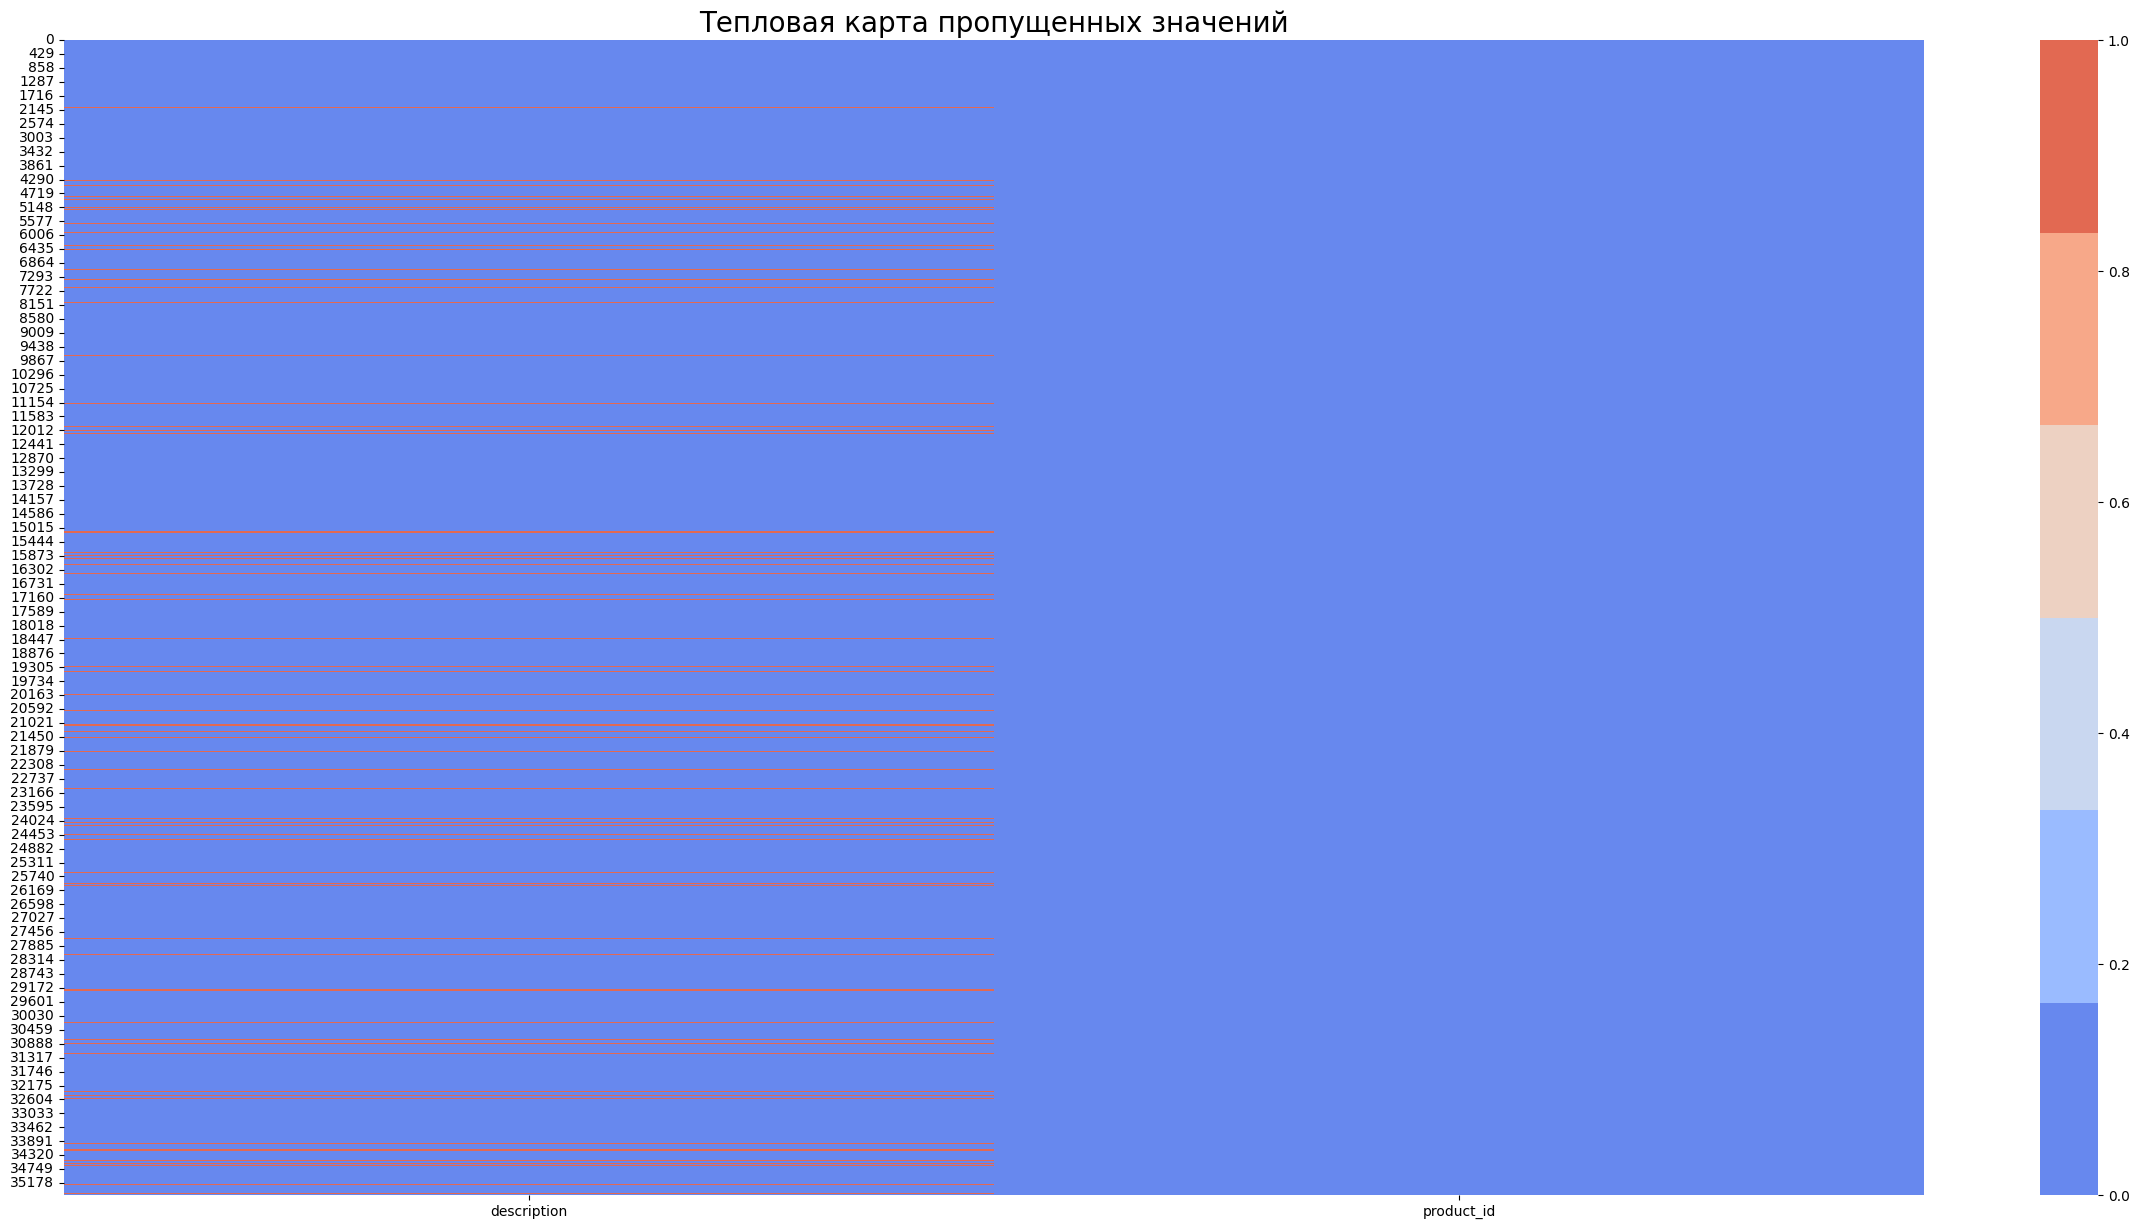

---------------------------------------------------------------------------------------------------------------------------


<Axes: title={'center': 'Тепловая карта пропущенных значений'}>

In [14]:
# Выводим количество пропусков
missing_values_count(
    data = products_df,
    data_name = 'products_df',
    length = 50
)
print('\n')



# Выводим тепловую карту
missing_values_heatmap(data = products_df)

Из расчёта количества пропусков видно, что пропуски имеют следующие признаки: `product_id` и `descrirption`.

Удалим строки, содержащие пропуски:

In [15]:
# Создаём список факторов, в которых присутствуют пропуски
features_with_null = [column for column in products_df.columns if products_df[column].isna().sum() > 0]

# Удаляем строки с пропусками
products_df = products_df.dropna(subset = features_with_null)



# Выводим суммарное количество пропусков после обработки
print(f'\nСуммарное количество пропусков в данных после обработки: {products_df.isnull().sum().sum()}')
print('-' * 60)


Суммарное количество пропусков в данных после обработки: 0
------------------------------------------------------------


#### $2.2$

#### **Проверяем данные на наличие дубликатов:**

In [16]:
# Создаём список признаков
dupl_columns = list(products_df.columns)


# Создаём маску дубликатов с помощью метода duplicated() и произведём фильтрацию
mask = products_df.duplicated(subset = dupl_columns)
products_duplicates = products_df[mask]
print(f'\nЧисло найденных дубликатов: {products_duplicates.shape[0]}')
print('-' * 30)


Число найденных дубликатов: 0
------------------------------


=============================================================================================================================================

## <CENTER> **`3.` Feature engineering (предобработка данных)**

На данном этапе преобразуем все текстовые признаки.

#### $3.1$

#### **Предобработка текста.**

Создадим функцию для предобработки текста:

In [17]:
# Создаём объект класса MorphAnalyzer()
morpher = pymorphy3.MorphAnalyzer()

# Задаём множество Русских слов
stop_words = set(stopwords.words('russian'))
sw = set(stop_words)



# Создаём функцию для преобразования текста
def preprocess_txt(line):
    
    # Почистим строку от пунктуации. Для этого пробежимся по каждому символу и проверим, не является ли он знаком пунктуации
    exclude = set(string.punctuation)
    spls = ''.join(i for i in line.strip() if i not in exclude).split()
    
    # Лемматизируем все слова в нашем тексте
    spls = [morpher.parse(i.lower())[0].normal_form for i in spls]
    spls = [i for i in spls if i not in sw and i != '']
    
    # Возвращаем результат
    return spls

Преобразуем признаки `title` и `description`:

In [18]:
# Создаём список обрабатываемых признаков
features_to_preprocess = [
    'title',
    'description'
]


# Применяем функцию для предобработки к данным столбцам
for feature in products_df[features_to_preprocess]:
    products_df[feature] = products_df[feature].apply(lambda x: preprocess_txt(x))

Выведем итоговый **DataFrame:**

In [19]:
# Выводим информацию по полученной таблице 'products_df' 
check_data_inf(
    data = products_df.head(),
    data_name = 'products_df',
    length1 = 40,
    length2 = 110
) 


============================| Данные таблицы "products_df" имеют следующую структуру |============================

Количество строк: 5;
Количество признаков (столбцов): 4.
----------------------------------------


,title,description,product_id,is_product
0,"[юбка, детский, orby]","[новый, носить, реал, красивый, фото]",58e3cfe6132ca50e053f5f82,0
1,[ботильон],"[новыепривезти, чехия, указать, размер, 40ный,...",5667531b2b7f8d127d838c34,0
2,[брюки],"[размер, 4042, брюки, новый, знать, мерило, по...",59534826aaab284cba337e06,0
3,"[продать, детский, шапка]","[продать, шапкикажда, 200ррозовый, белый, прод...",57de544096ad842e26de8027,0
4,[блузка],"[темносиний, 42, размерсостояние, отличноекак,...",5ad4d2626c86cb168d212022,0


--------------------------------------------------------------------------------------------------------------


#### $3.2$

Преобразуем выделенные слова обратно в строки:

In [20]:
# Преобразовываем списки в строки
products_df['title'] = products_df['title'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
products_df['description'] = products_df['description'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)


# Объединяем признаки 'title' и 'description' в один столбец
products_df['text'] = products_df['title'] + ' ' + products_df['description']

Выведем итоговый **DataFrame:**

In [21]:
# Выводим информацию по полученной таблице 'products_df' 
check_data_inf(
    data = products_df.head(),
    data_name = 'products_df',
    length1 = 40,
    length2 = 123
) 


============================| Данные таблицы "products_df" имеют следующую структуру |============================

Количество строк: 5;
Количество признаков (столбцов): 5.
----------------------------------------


,title,description,product_id,is_product,text
0,юбка детский orby,новый носить реал красивый фото,58e3cfe6132ca50e053f5f82,0,юбка детский orby новый носить реал красивый фото
1,ботильон,новыепривезти чехия указать размер 40ный малом...,5667531b2b7f8d127d838c34,0,ботильон новыепривезти чехия указать размер 40...
2,брюки,размер 4042 брюки новый знать мерило покупка н...,59534826aaab284cba337e06,0,брюки размер 4042 брюки новый знать мерило пок...
3,продать детский шапка,продать шапкикажда 200ррозовый белый проданна,57de544096ad842e26de8027,0,продать детский шапка продать шапкикажда 200рр...
4,блузка,темносиний 42 размерсостояние отличноекак новы...,5ad4d2626c86cb168d212022,0,блузка темносиний 42 размерсостояние отличноек...


---------------------------------------------------------------------------------------------------------------------------


=============================================================================================================================================

## <CENTER> **`4.` Векторизация текста**

Произведём векторизацию текста для преобразования текстовых данных в числовые векторы, что бы использовать текст в качестве входных данных для алгоритмов машинного обучения.

#### $4.1$

#### **Разделим данные на обучающую и валидационную выборки.**

Сформируем матрицу наблюдения $X$, вектор целевой переменной $y$:

In [22]:
# Разделение на признаки X и целевую переменную y
X = products_df['text']
y = products_df['is_product']



# Разделяем данные на обучающую и валидационную выборки
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, 
    test_size = 0.25, 
    random_state = 42, 
    shuffle = True
)

#### $4.2$

#### **Производим векторизацию признаков.**

Воспользуемся методом **TfidfVectorizer()** для векторизации признаков:

In [23]:
# Инициализация TfidfVectorizer()
tfidf_vectorizer = TfidfVectorizer(
    max_features = 10000,
    stop_words = stopwords.words('russian')
)

# Векторизация признаков
X_train_vec = tfidf_vectorizer.fit_transform(X_train)
X_valid_vec = tfidf_vectorizer.transform(X_valid)



# Проверка размеров
print('\n============| Итоговые размерности данных |============\n\n')
print("X_train_vec shape:", X_train_vec.shape)
print("X_valid_vec shape:", X_valid_vec.shape)
print('-' * 35)


============| Итоговые размерности данных |============


X_train_vec shape: (25150, 10000)
X_valid_vec shape: (8384, 10000)
-----------------------------------


#### $4.3$

#### **Балансировка целевой переменной.**

Проверим распределение классов целевой переменной. 

Создадим функцию для построения графика распределения целевого признака:

In [24]:
# Создаём функцию для построения графика распределения медианного значения целевой переменной
def target_distribution_plot(target, title1, color_palette, main_title, figsize):
    
    
    '''
    
    Функция для построения графика распределения целевой переменной.
    
    Параметры:
      - target: pandas Series с данными.
      - title1: заголовок графика.
      - color_palette: палитра цветов.
      - main_title: главный заголовок.
      - figsize: размер графика.
      
    '''

    
    # Задаём заглавие для графика
    print(f'\n\n======================| {main_title} |======================')
    print('-' * 123)
    
    
    
    # Задаём размер графика
    fig, ax = plt.subplots(1, 2, figsize = figsize)

    # Гистограмма
    sns.countplot(
        x = target,
        hue = target,
        ax = ax[0],
        palette = color_palette,
        order = target.value_counts().index,
        edgecolor = 'black',
        linewidth = 1.5,
        legend = False
    )

    ax[0].tick_params(axis = 'x', labelsize = 15)
    ax[0].set_title(title1, fontsize = 20)
    ax[0].set_xlabel('Класс', fontsize = 15)
    ax[0].set_ylabel('Количество', fontsize = 15)
    plt.grid(True, linestyle = '--', alpha = 0.7)
    plt.tight_layout()



    # Кольцевая диаграмма
    target_counts = target.value_counts()
    wedges, texts, autotexts = ax[1].pie(
        target_counts,
        labels = target_counts.index,
        colors = sns.color_palette(color_palette, len(target_counts)),
        autopct = '%1.1f%%',
        startangle = 90
    )

    centre_circle = plt.Circle((0, 0), 0.70, fc = 'white')
    fig.gca().add_artist(centre_circle)
    ax[1].set_title(title1, fontsize = 20)



    # Выводим график
    plt.show()
    print('-' * 123)

Создадим функцию для построения графика распределения медианного знаяения целевого признака:

In [25]:
# Создаём функцию для построения графика распределения целевой переменной
def median_target_distribution_plot(data, target, median_target, title, main_title, figsize):
    
    
    '''
    Функция для построения графика распределения целевой переменной.
    
    Параметры:
      - data: данные,
      - target: pandas Series с данными,
      - median_target: медианное значение целевой переменной,
      - title: заголовок графика,
      - main_title: название графика,
      - figsize: размер графика.
    
    '''
    
    
    # Задаём заглавие для графика
    print(f'\n\n======================| {main_title} |======================')
    print('-' * 123)
    
    
    # Задаём размер графика
    plt.figure(figsize = figsize)
    
    # Строим график
    sns.histplot(
        data = data,
        x = target,
        bins = 50,
        kde = True
    )
    
    # Создаём вертикальную красную линию медианного значения
    plt.axvline(
        x = median_target,
        color = 'red',
        linestyle = '--',
        label = f'Median = {median_target}'
    )
    
    # Задаём параметры графика
    plt.title(title, fontsize = 20)
    plt.xlabel(target, fontsize = 16)
    plt.ylabel('Count', fontsize = 16)
    plt.xticks(fontsize = 10)                          # размер шрифта для подписей по оси X
    plt.yticks(fontsize = 10)                          # размер шрифта для подписей по оси Y
    plt.grid(True, linestyle = '--', alpha = 0.7)
    plt.legend(fontsize = 10)                          # размер шрифта для легенды
    
    # Убираем лишние пробелы в названиях столбцов
    plt.tight_layout()  
    
    
    
    # Выводим график
    plt.show()   
    print('-' * 123)

Построим график распределения целевой переменной:


Медианное значение IC50: 0.0
------------------------------





======================| Стобчатая и круговая диаграммы распределения целевой переменной: |======================
---------------------------------------------------------------------------------------------------------------------------


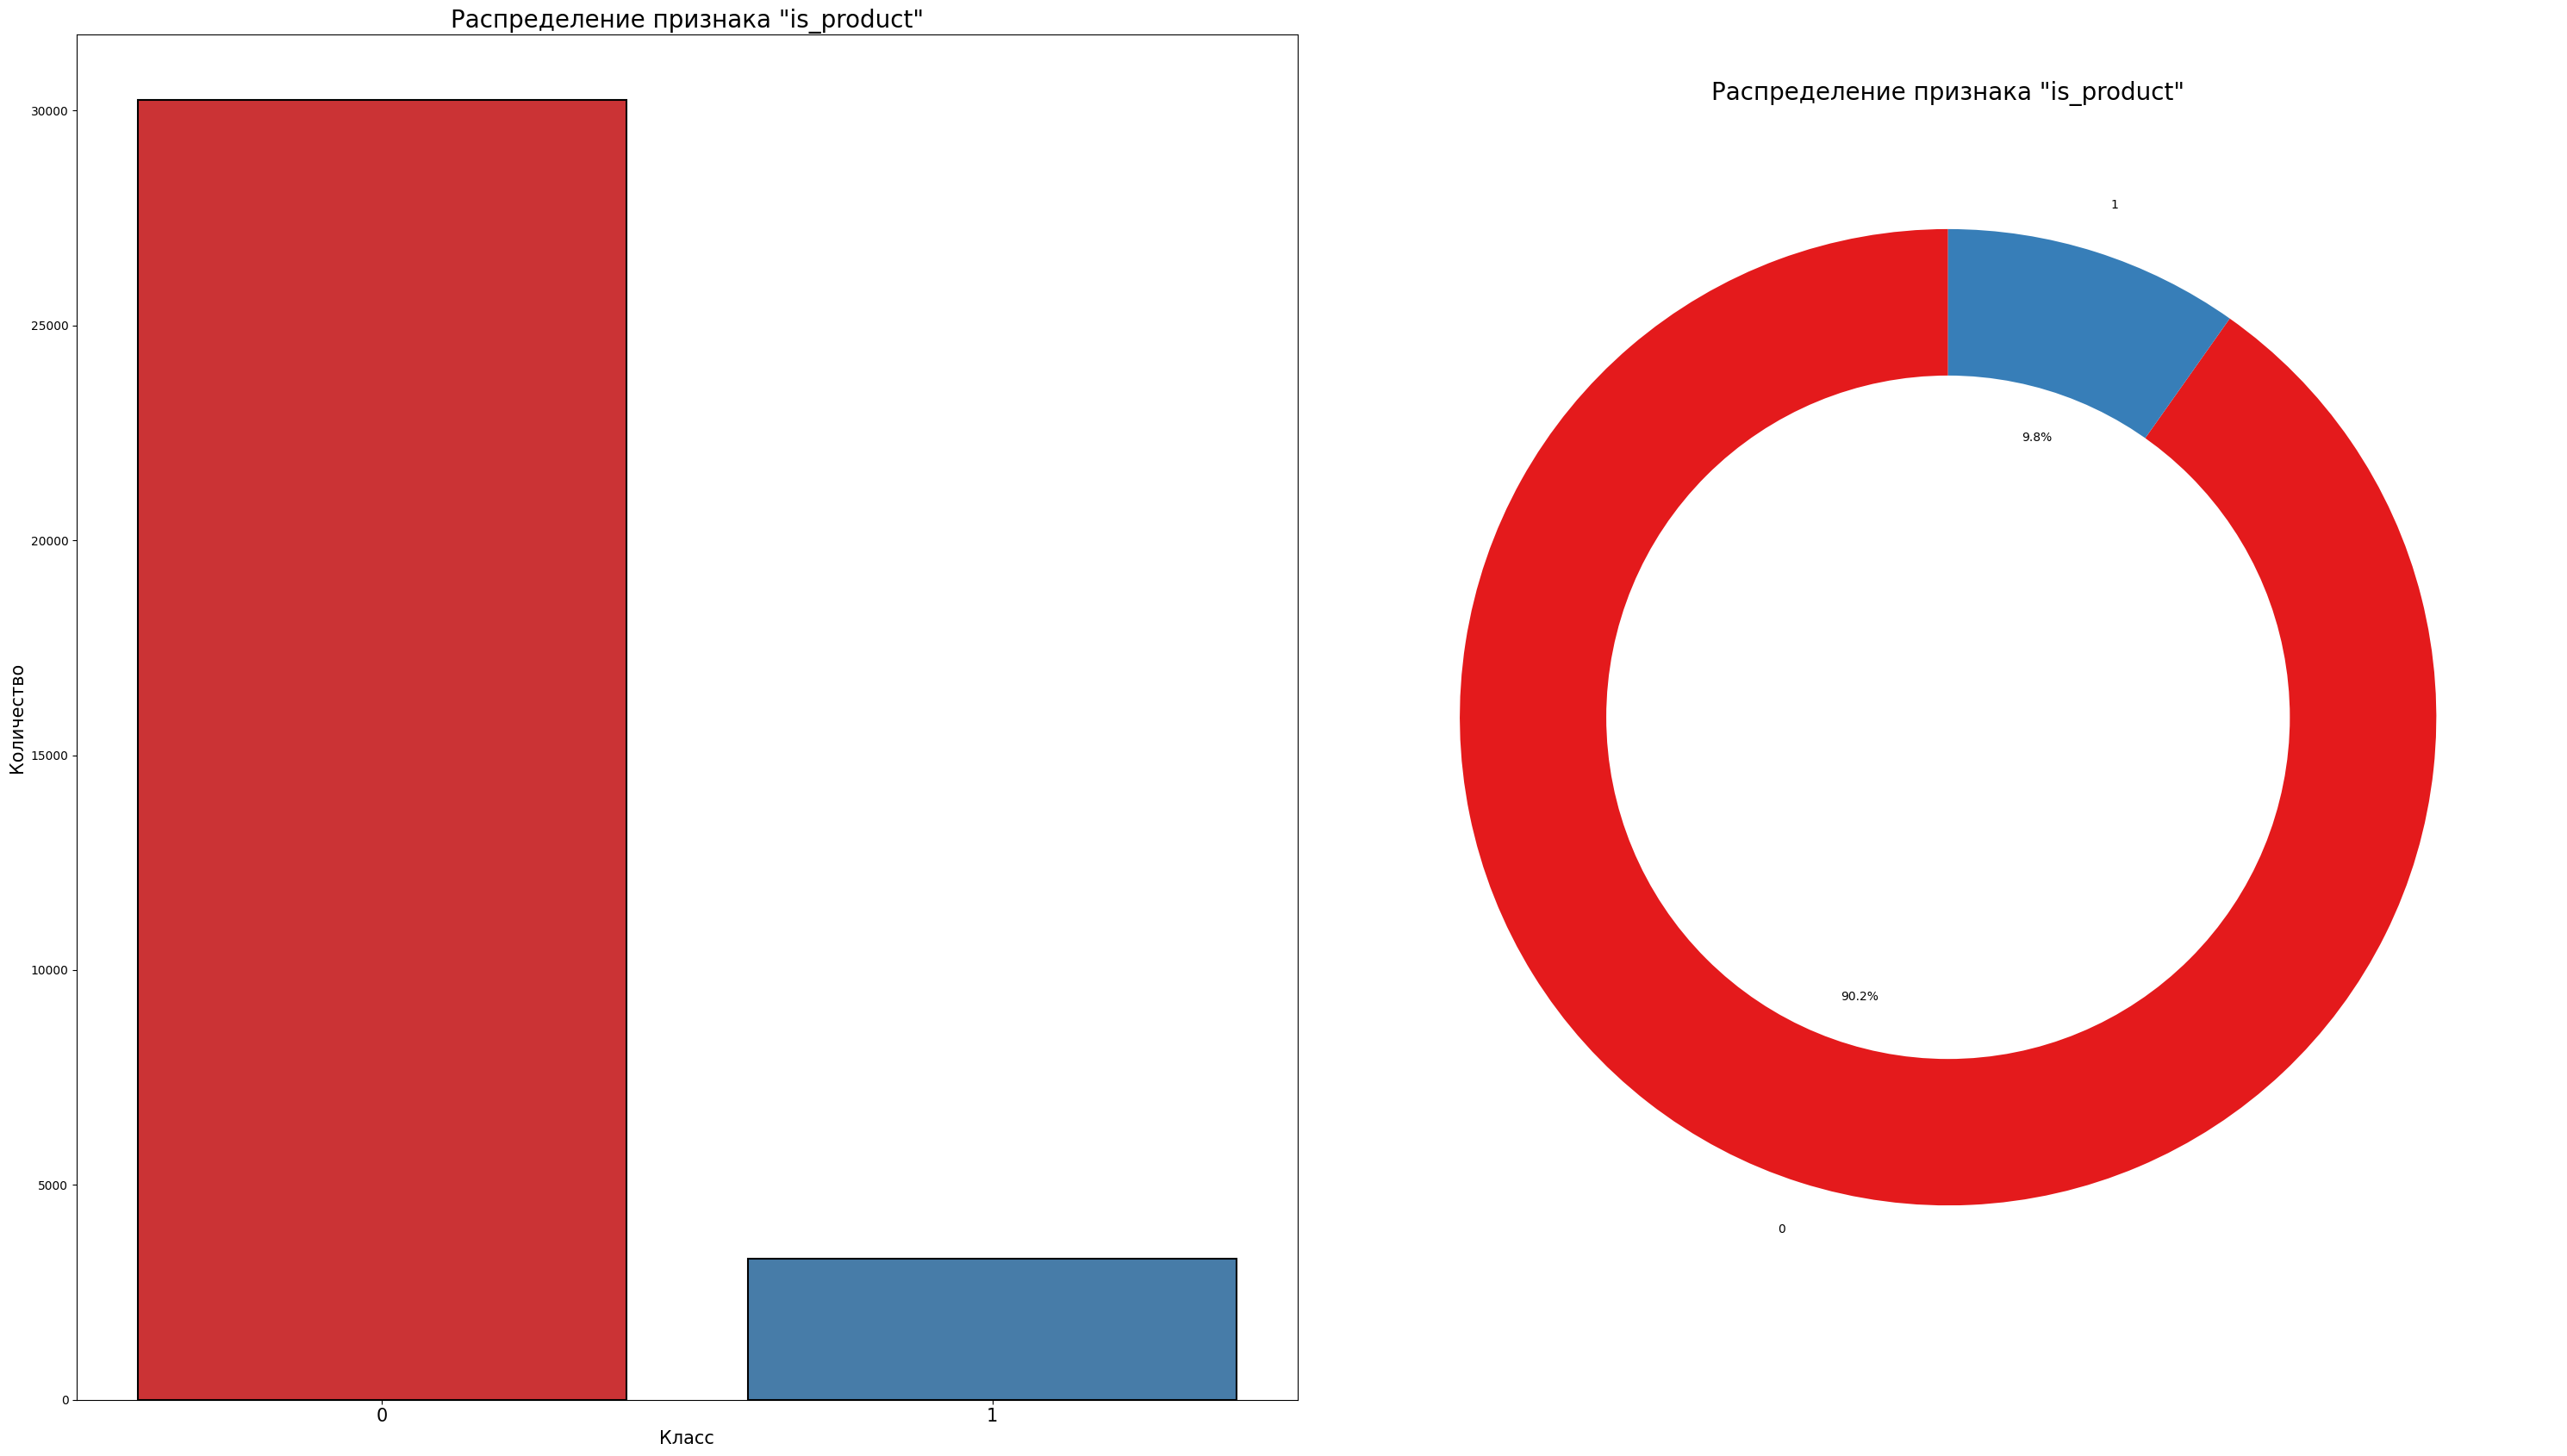

---------------------------------------------------------------------------------------------------------------------------




======================| Распределение целевой переменной |======================
---------------------------------------------------------------------------------------------------------------------------


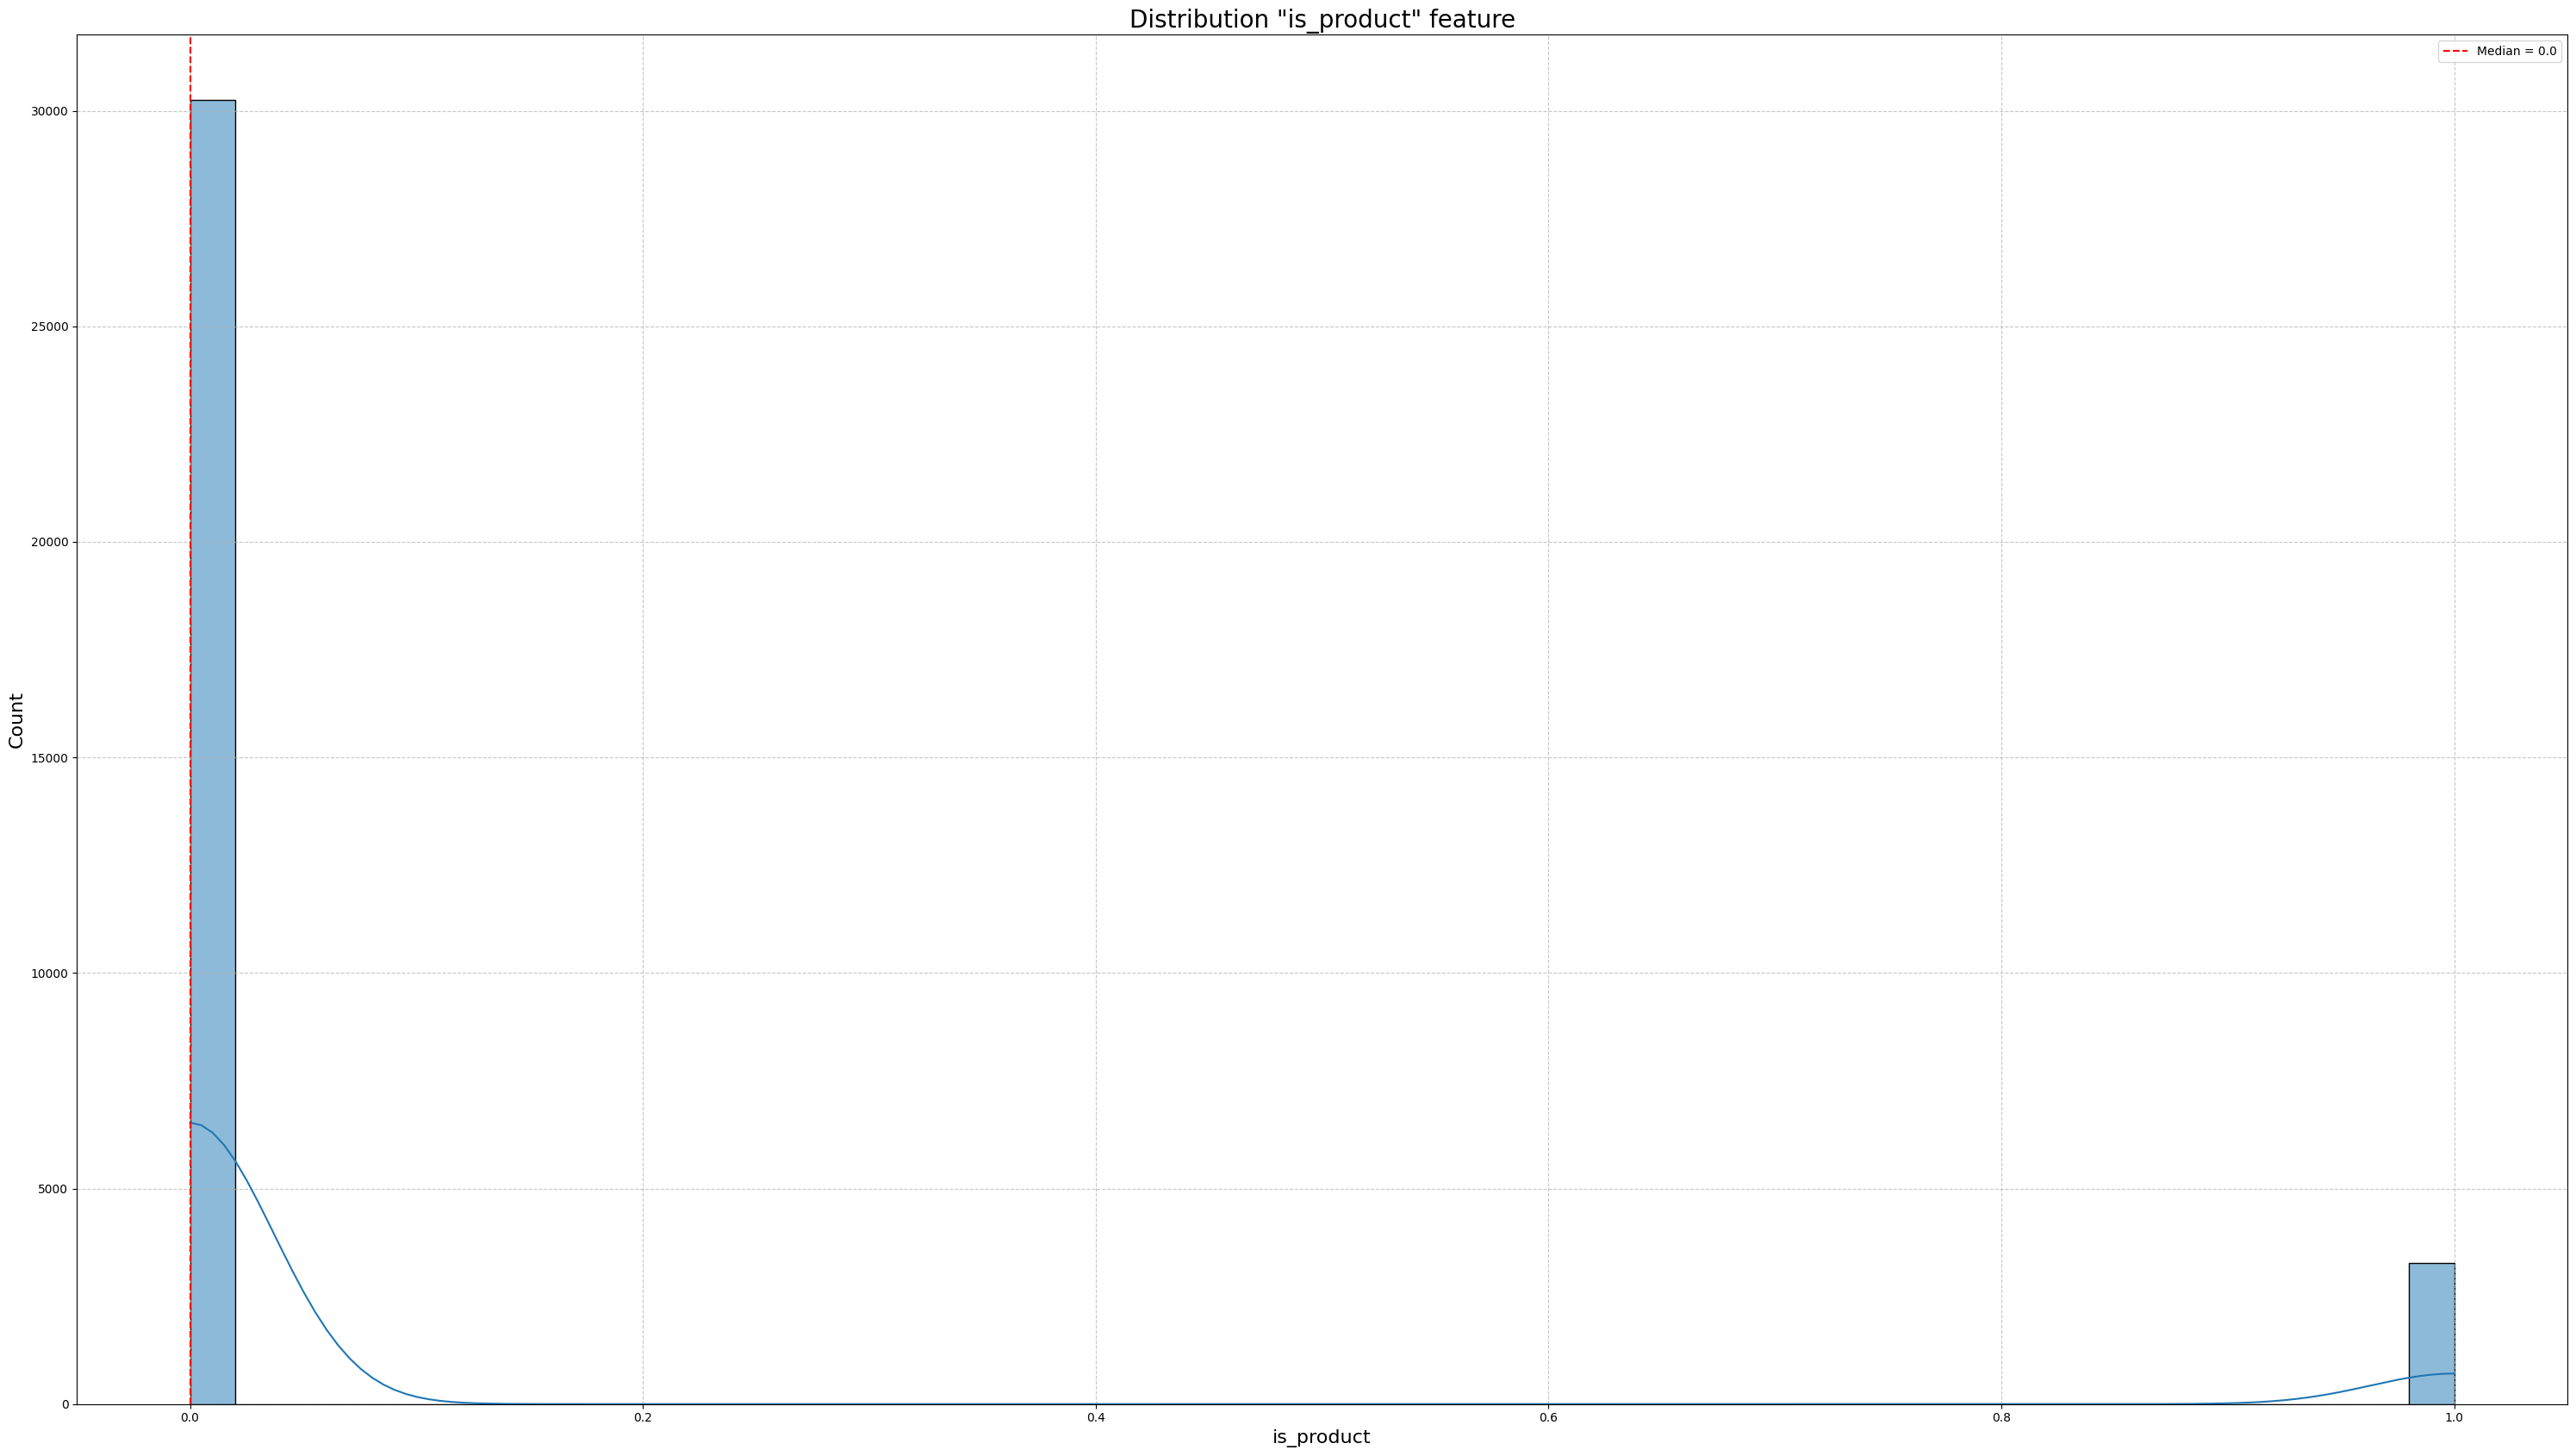

---------------------------------------------------------------------------------------------------------------------------


In [27]:
# Вычисляем медиану IC50
median_is_product = products_df['is_product'].median()
print(f'\nМедианное значение IC50: {median_is_product}')
print('-' * 30)
print('\n\n')




# Применяем функцию 'target_distribution_plot()' для построения графика распределения целевой переменной
target_distribution_plot(
    target = products_df['is_product'],
    title1 = 'Распределение признака "is_product"',
    main_title = 'Стобчатая и круговая диаграммы распределения целевой переменной:',
    color_palette = 'Set1',
    figsize = (30, 17)
)
print('\n')

# Применяем функцию 'median_target_distribution_plot()' для построения графика распределения целевой переменной
median_target_distribution_plot(
    data = products_df,
    target = 'is_product',
    median_target = median_is_product,
    title = 'Distribution "is_product" feature',
    main_title = 'Распределение целевой переменной',
    figsize = (30, 17)
)

**Вывод:**

Из построенной столбчатой диаграммы виден явный дисбаланс, особенно выделяется преобладание класса $0$ ($90.2$%) над $1$ ($9.8$%).

Для дальнейшей работы требуется балансировка классов.

Сбалансируем классы. Для этого воспользуемся алгоритмом `RandomOverSampler`, который отлично подходит для случаев с экстремально малым количеством данных в классе:

In [28]:
# Балансировка с RandomOverSampler
ros = over_sampling.RandomOverSampler(random_state = 42)

# Применение RandomOverSampler для создания сбалансированных данных
X_train_vec_res, y_train_res = ros.fit_resample(X_train_vec, y_train)

Построим график распределения целевой переменной после применения оверсемплинга:


=========================| Структура данных после применения "RandomOverSampler" |=========================


Размерность данных после применения RandomOverSampler: (45446, 10000)
----------------------------------------------------------------------



Распределение классов после применения RandomOverSampler:

is_product
0    22723
1    22723
Name: count, dtype: int64
-----------------------------------------------------------------





======================| Стобчатая и круговая диаграммы распределения целевой переменной: |======================
---------------------------------------------------------------------------------------------------------------------------


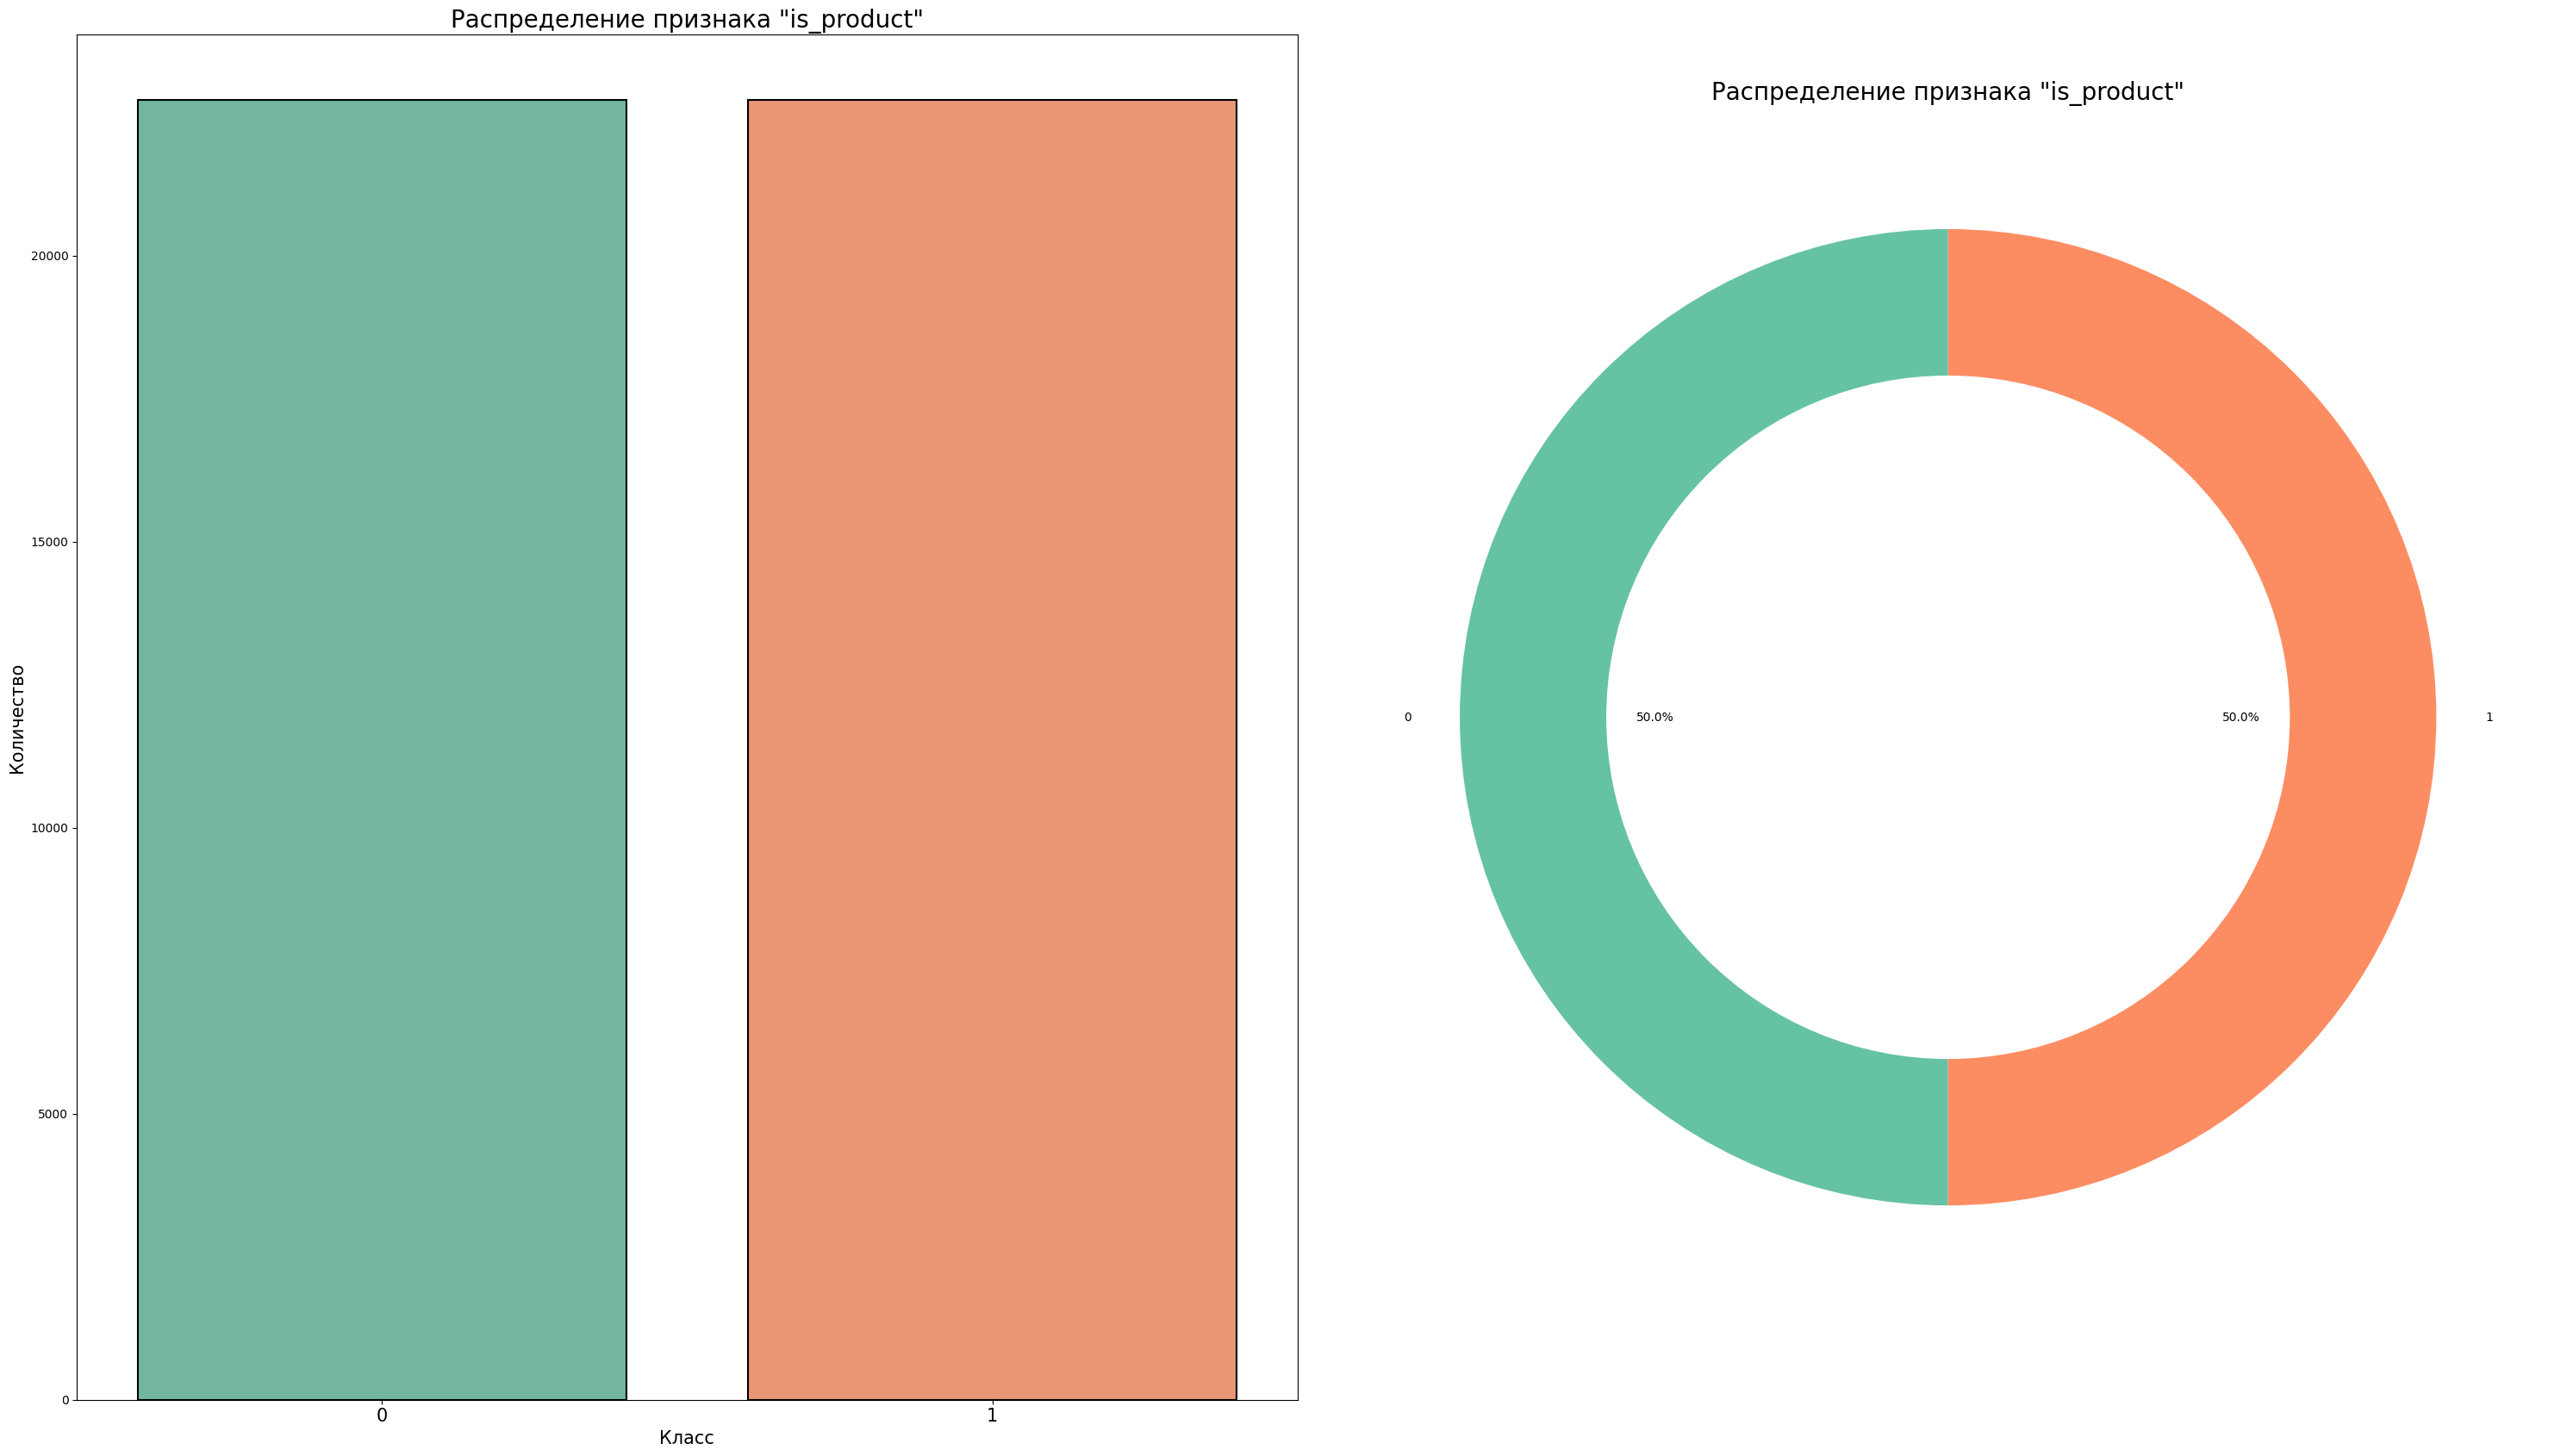

---------------------------------------------------------------------------------------------------------------------------


In [29]:
# Вывод информации о сбалансированных данных
print('\n=========================| Структура данных после применения "RandomOverSampler" |=========================\n')
print(f'\nРазмерность данных после применения RandomOverSampler: {X_train_vec_res.shape}')
print('-' * 70)
print('\n\n')

print(f'Распределение классов после применения RandomOverSampler:\n\n{y_train_res.value_counts()}')
print('-' * 65)
print('\n\n')



# Применяем функцию 'target_distribution_plot()' для построения графика распределения целевой переменной
target_distribution_plot(
    target = y_train_res,
    title1 = 'Распределение признака "is_product"',
    main_title = 'Стобчатая и круговая диаграммы распределения целевой переменной:',
    color_palette = 'Set2',
    figsize = (30, 17)
)

Теперь данные распределены нормально.

=============================================================================================================================================

## <CENTER> **`5.` Machine Learning**

На данном этапе обучим классификатор с расчётом метрик на валидации.

**Определение метрик.**

Используем следующие метрики для оценки:

  * `Accuracy`:________________(метрика точности),

  * `Precision`:_______________(положительное прогнозное значение),

  * `Recall`:__________________(доля истинно положительных результатов),

  * `F1-score`:________________(среднее значение Точности измерений),

  * `Classification report`:___(таблица рассчитанных метрик).

Создадим функцию для вычисления метрик:

In [30]:
# Создаём функцию 'print_metrics'       
def print_metrics(y_true, y_predict, model_name, decimal_places = 3):
    
    
    '''
    Вычисляет и выводит метрики (Accuracy, Precision, Recall, F1-score, Classification report) для оценки модели.
    
    Параметры:
    - y_true: истинные значения (например, y_valid)
    - y_pred: предсказанные значения (например, y_log_predict)
    - model_name: строка с названием модели (например, "LogisticRegression")
    - decimal_places: количество знаков после запятой для форматирования (по умолчанию 3)
    
    '''
    
    
    # Вычисляем метрики
    accuracy_metric = metrics.accuracy_score(y_true, y_predict)
    precision_metric = metrics.precision_score(y_true, y_predict, average = 'weighted')
    recall_metric = metrics.recall_score(y_true, y_predict, average = 'weighted')
    f1_metric = metrics.f1_score(y_true, y_predict, average = 'weighted')
    cr_metrics = metrics.classification_report(y_true, y_predict)
    
    
    # Выведем результат
    print(f'\n=============================| {model_name} (значения метрик) |=============================\n')
    print(f'Accuracy: {accuracy_metric:.{decimal_places}f}')
    print('-' * 17)
    print(f'Precision: {precision_metric:.{decimal_places}f}')
    print('-' * 17)
    print(f'Recall: {recall_metric:.{decimal_places}f}')
    print('-' * 17)
    print(f'F1-score: {f1_metric:.{decimal_places}f}')
    print('-' * 17)
    print()
    print(f'Classification report:\n\n{cr_metrics}')
    print('-' * 60)

#### $5.1$

#### **Обучение классификатора `LogisticRegression()` с использованием `GridSearchCV`.**

Мы будем использовать логистическую регрессию для классификации с применением алгоритма для перебора гиперпараметров `GridSearchCV`:

In [31]:
# Создаём объект класса LogisticRegression()
Log_model = linear_model.LogisticRegression(
    random_state = 42,
    class_weight = 'balanced'
)



# Определение пространства поиска гиперпараметров
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}



# Создаём объект класса 'GridSearchCV' с определёнными гиперпараметрами
grid_search = model_selection.GridSearchCV(
    estimator = Log_model,
    param_grid = param_grid,
    cv = 5,
    verbose = 2,
    n_jobs = -1
)

# Обучаем алгоритм 'GridSearchCV'
grid_search.fit(X_train_vec_res, y_train_res)

# Делаем предсказание для валидационной выбороки
y_predict = grid_search.predict(X_valid_vec)



# Выводим лучшие гиперпараметры
print(f'\nBest parameters: {grid_search.best_params_}')
print('-' * 30)

Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best parameters: {'C': 100}
------------------------------


Вычисление метрик:

In [32]:
# Для вычисления и вывода метрик применим функцию 'print_metrics'           
print_metrics(
    y_true = y_valid,
    y_predict = y_predict,
    model_name = 'LogisticRegression'
)


=============================| LogisticRegression (значения метрик) |=============================

Accuracy: 0.983
-----------------
Precision: 0.984
-----------------
Recall: 0.983
-----------------
F1-score: 0.984
-----------------

Classification report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7529
           1       0.90      0.95      0.92       855

    accuracy                           0.98      8384
   macro avg       0.95      0.97      0.96      8384
weighted avg       0.98      0.98      0.98      8384

------------------------------------------------------------


Сохранение модели и векторизатора:

In [33]:
# Сохранение модели и векторизатора в pickle-файлы
with open('logistic_model.pkl', 'wb') as model_file:
    pickle.dump(grid_search, model_file)
    
with open('vectorizer.pkl', 'wb') as vectorizer_file:
    pickle.dump(tfidf_vectorizer, vectorizer_file)
    
print('\nМодель и векторизатор успешно сохранены!')
print('-' * 40)


Модель и векторизатор успешно сохранены!
----------------------------------------


Загрузка модели и применение:

In [34]:
# Загрузка модели и векторизатора
with open('logistic_model.pkl', 'rb') as model_file:
    loaded_model = pickle.load(model_file)
    
with open('vectorizer.pkl', 'rb') as vectorizer_file:
    loaded_vectorizer = pickle.load(vectorizer_file)
    
    
    
# Пример новых данных
new_data = [
    'новая юбка для девочки',
    'продам ботинки белого цвета'
]



# Преобразование новых данных с помощью загруженного векторизатора
new_data_vec = loaded_vectorizer.transform(new_data)

# Предсказания с помощью загруженной модели
predictions = loaded_model.predict(new_data_vec)

print(f'\nПредсказания для новых данных: {predictions}')
print('-' * 40)


Предсказания для новых данных: [0 0]
----------------------------------------


=============================================================================================================================================

## <CENTER> **`6.` Реализация поиска похожих товаров в контентной части бота**

На данном этапе проведём токенизацию текстов, обучим модель `Word2Vec` а так же получим векторы названий.

#### $6.1$

#### **Все названия товаров свернём в векторное представление *Word2Vec.***

Преобразовываем данные:

In [35]:
# Создаем маску для выбора только тех строк, где 'is_product' равен 1
filtered_data = products_df[products_df['is_product'] == 1]


# Преобразовываем все записи признака 'title' в текстовый формат,
# так же проведём токенизацию
titles = filtered_data['title'].astype(str).tolist()
title_tokens = [re.findall(r'\w+', title.lower().replace("'", "")) for title in titles]



# Выводим результат
print('\n======================| Результат проведения токенизации текстов |======================\n')
display(title_tokens)


======================| Результат проведения токенизации текстов |======================



[['платье'],
 ['коктейльный', 'платье'],
 ['платье', 'новый'],
 ['нарядный', 'новогодний', 'платье', 'снежинка'],
 ['платьетуник'],
 ['вечерний', 'платье'],
 ['платье'],
 ['платье'],
 ['платье', 'ползунок', 'новый'],
 ['платье', 'праздничный'],
 ['свадебный', 'платье'],
 ['платье', 'искусственный', 'шёлк'],
 ['шикарный', 'платье'],
 ['продаваться', 'платье', 'девочка'],
 ['платье', 'новый'],
 ['платье', 'новый', 'италия'],
 ['платье'],
 ['новый', 'платье', '4244'],
 ['платьекомбишорты'],
 ['платье'],
 ['платье', 'женский'],
 ['вечерний', 'платье'],
 ['платье'],
 ['вечерний', 'платье'],
 ['платье'],
 ['свадебный', 'платье'],
 ['платье', 'нарядный', 'девочка'],
 ['новый', 'платье', 'zara', '48', 'размер', 'l'],
 ['свадебный', 'платье', 'topaza', 'pella'],
 ['новый', 'платьеочень', 'красивое'],
 ['платье', 'болохон', 'р', '4850'],
 ['платье', '52', '54'],
 ['новый', 'платье', 'болеро', 'silver', 'string'],
 ['платье'],
 ['платье'],
 ['платье'],
 ['платье', 'кружевной', 'болеро'],
 ['плать

Обучаем модель `Wor2Vec`:

In [36]:
# Обучение модели Word2Vec
W2V_model = models.Word2Vec(
    sentences = title_tokens,  
    vector_size = 100,
    window = 5,
    min_count = 2,
    workers = 4,
    seed = 42
)

Создаём функцию для получения векторов для названий:

In [37]:
# Создадим функцию для получения векторов для каждого названия
def get_title_vector(title_tokens, model):
    
    
    '''
    
    Функция для преобразования списка токенов в вектор.
    Усредняет векторы токенов, если они существуют в модели.
    
    Параметры:
      - title_tokens  : токенизированные названия
      - model         : модель
    
    '''
    
    
    # Проверяем, есть ли токен в словаре Word2Vec
    vectors_list = [model.wv[word] for word in title_tokens if word in model.wv]
    
    
    # Если в списе содержатся элементы, заполняем средним значением,
    # в противном случае - нулями
    return np.mean(vectors_list, axis = 0) if vectors_list else np.zeros(model.vector_size)

Получаем векторы для каждого названия в наборе данных:

In [38]:
# Векторизация названий
vectorized_titles = np.array([get_title_vector(tokens, W2V_model) for tokens in title_tokens])


# Пример: извлечение векторов для первого товара
print(f'\nВектор для первого названия:\n\n{vectorized_titles[0]}')
print('-' * 75)


Вектор для первого названия:

[-0.10315423  0.12342726  0.0399849   0.01281757 -0.05105346  0.32167366
  0.00692294  0.10300485 -0.2361709  -0.0808838  -0.1660845   0.21549904
  0.05400959  0.15107094 -0.03904368 -0.07049311  0.0092723  -0.30981478
 -0.09311948 -0.06605389  0.00056231  0.02333446  0.02582768  0.27478459
  0.32492363  0.08746604 -0.25387225  0.15560618 -0.05443293 -0.10812774
 -0.08357422 -0.10561392 -0.08734323 -0.00440723  0.08521891 -0.24546058
  0.0757081  -0.04240134 -0.07834034  0.04092853  0.03135689 -0.02782945
  0.12819763 -0.04854882 -0.09907474  0.22837386 -0.01002596  0.23488462
  0.22738308  0.07857066  0.07486057 -0.20985328 -0.0343054   0.01963988
  0.12768225 -0.18119246 -0.07093055 -0.04811766  0.08082999  0.10059802
  0.07918685  0.12344525 -0.14325565  0.13331005 -0.03120228 -0.08929025
  0.03511081 -0.19244671 -0.18844138 -0.11453478  0.05869318 -0.18699612
 -0.02873677 -0.12002736  0.08589888  0.05287417  0.03524932 -0.20719786
  0.05096039 -0.1052

Добавление векторов в *DataFrame*:

In [39]:
# Создание DataFrame с векторами и индексами
vectorized_df = pd.DataFrame(
    vectorized_titles,
    index = filtered_data.index
)

# Объединяем с filtered_data
filtered_data = filtered_data.join(vectorized_df)



# Выводим фтруктуру 'vectorized_df' и 'filtered_data'               
check_data_inf(
    data = vectorized_df,
    data_name = 'vectorized_df',
    length1 = 40,
    length2 = 123
)
print('\n\n\n')


check_data_inf(
    data = filtered_data.head(),
    data_name = 'filtered_data',
    length1 = 40,
    length2 = 123
)


============================| Данные таблицы "vectorized_df" имеют следующую структуру |============================

Количество строк: 3282;
Количество признаков (столбцов): 100.
----------------------------------------


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
8,-0.103154,0.123427,0.039985,0.012818,-0.051053,0.321674,0.006923,0.103005,-0.236171,-0.080884,...,-0.215615,0.302165,0.212648,-0.093397,0.219331,-0.205019,0.033623,0.096792,-0.092911,-0.036194
13,-0.052324,0.073303,0.020323,0.009855,-0.031434,0.179602,0.001745,0.057393,-0.128382,-0.045371,...,-0.125794,0.164738,0.123855,-0.048693,0.124419,-0.111381,0.014893,0.049840,-0.054262,-0.024678
15,-0.074365,0.090905,0.033245,0.005244,-0.036294,0.250453,0.010234,0.080691,-0.181903,-0.058364,...,-0.164986,0.234250,0.164563,-0.073394,0.172330,-0.161950,0.025866,0.070121,-0.074502,-0.021452
26,-0.046951,0.052486,0.019796,0.010288,-0.023556,0.140025,0.003497,0.044061,-0.102052,-0.035830,...,-0.094010,0.136215,0.087159,-0.037509,0.092377,-0.087334,0.018827,0.041730,-0.039295,-0.015819
27,-0.005139,0.003254,0.008601,-0.006532,-0.013727,0.022252,0.000655,0.012026,-0.023932,-0.014470,...,-0.029036,0.025802,0.020443,-0.016985,0.016043,-0.025904,0.003511,0.013252,0.000103,-0.004885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35428,-0.057876,0.059586,0.022062,0.003276,-0.025896,0.172198,0.005725,0.054448,-0.126946,-0.042069,...,-0.107875,0.161514,0.110383,-0.049775,0.115707,-0.108691,0.018712,0.055368,-0.051622,-0.016030
35435,-0.060001,0.073371,0.017865,0.006911,-0.025997,0.187387,0.002123,0.059952,-0.137310,-0.049377,...,-0.120504,0.167268,0.119477,-0.053770,0.129109,-0.116166,0.019853,0.051334,-0.050248,-0.021734
35437,-0.054903,0.060285,0.022830,0.006313,-0.024283,0.171085,0.006739,0.054056,-0.129722,-0.046206,...,-0.113723,0.157361,0.114425,-0.044548,0.112832,-0.110807,0.014168,0.053343,-0.049692,-0.021043
35485,-0.042061,0.052862,0.018742,0.003553,-0.025431,0.150134,0.004143,0.045244,-0.109620,-0.034734,...,-0.100635,0.141770,0.101807,-0.043952,0.100899,-0.092707,0.016723,0.044427,-0.047347,-0.010158


---------------------------------------------------------------------------------------------------------------------------





============================| Данные таблицы "filtered_data" имеют следующую структуру |============================

Количество строк: 5;
Количество признаков (столбцов): 105.
----------------------------------------


,title,description,product_id,is_product,text,0,1,2,3,4,...,90,91,92,93,94,95,96,97,98,99
8,платье,одеть 1 концерт всё 44 размер сидеть фигура оч...,58b5a3db5bd2e984409293d3,1,платье одеть 1 концерт всё 44 размер сидеть фи...,-0.103154,0.123427,0.039985,0.012818,-0.051053,...,-0.215615,0.302165,0.212648,-0.093397,0.219331,-0.205019,0.033623,0.096792,-0.092911,-0.036194
13,коктейльный платье,новогодний платье расшитый пайеткаминовой бель...,584d00fec5c2e6094986d5bf,1,коктейльный платье новогодний платье расшитый ...,-0.052324,0.073303,0.020323,0.009855,-0.031434,...,-0.125794,0.164738,0.123855,-0.048693,0.124419,-0.111381,0.014893,0.049840,-0.054262,-0.024678
15,платье новый,новый платье 4648размер красивый цвет смотреть...,579f280a96ad846334ee0dc5,1,платье новый новый платье 4648размер красивый ...,-0.074365,0.090905,0.033245,0.005244,-0.036294,...,-0.164986,0.234250,0.164563,-0.073394,0.172330,-0.161950,0.025866,0.070121,-0.074502,-0.021452
26,нарядный новогодний платье снежинка,нарядный платье украсить дождик одевать утренн...,582d65e21c40311a7ee60d97,1,нарядный новогодний платье снежинка нарядный п...,-0.046951,0.052486,0.019796,0.010288,-0.023556,...,-0.094010,0.136215,0.087159,-0.037509,0.092377,-0.087334,0.018827,0.041730,-0.039295,-0.015819
27,платьетуник,бархатный платьетуникарукать 34расшитый пайетк...,584d029ac97904a10b71d8ad,1,платьетуник бархатный платьетуникарукать 34рас...,-0.005139,0.003254,0.008601,-0.006532,-0.013727,...,-0.029036,0.025802,0.020443,-0.016985,0.016043,-0.025904,0.003511,0.013252,0.000103,-0.004885


---------------------------------------------------------------------------------------------------------------------------


#### $6.2$

#### **Построим индекс по названиям документов.**

Построение индекса:

In [40]:
# Сохраним индекс как список кортежей (вектор, название)
index = list(zip(vectorized_titles, titles))

#### $6.3$

#### **Для товарных запросов реализуем поиск в индексе (запрос также оборачивается *Word2Vec*, происходит проход в индекс).**

Поиск по запросу. Для поиска мы преобразуем запрос пользователя в вектор *Word2Vec* и найдем ближайшие названия товаров, сравнивая их с векторами в индексе. Для этого можно использовать косинусное сходство:

In [41]:
# Создаём функцию 'search_query'   
def search_query(query, model, index, top_n = 5):
    
    
    '''
    
    Функция для поиска в индексе по запросу.
    
    Параметры:
      - query: текстовый запрос
      - model: обученная модель Word2Vec
      - index: индекс (список векторов и названий)
      - top_n: количество наиболее релевантных результатов
    
    '''
    
    
    # Токенизация запроса
    query_tokens = re.findall(r'\w+', query.lower())
    
    # Преобразуем запрос в вектор
    query_vector = get_title_vector(query_tokens, model)
    
    
    
    # Сравниваем запрос с каждым элементом индекса
    similarities = [
        (cosine_similarity([query_vector], [vector])[0][0], title)
        for vector, title in index if np.linalg.norm(vector) > 0
    ]
    
    # Сортируем результаты по убыванию сходства
    similarities = sorted(similarities, key = lambda x: x[0], reverse = True)[: top_n]
    
    
    
    # Возвращаем топ-N результатов
    return similarities

Пример использования:

In [42]:
# Пример текстового запроса
query = 'брюки'


# Поиск по индексу
results = search_query(
    query,
    W2V_model,
    index,
    top_n = 5
)



# Вывод результатов
print('\n===================| Результаты поиска по индексу |===================\n')
for similarity, title in results:
    print(f'Название: {title}, Сходство: {similarity:.4f}') 
print('-' * 70)


===================| Результаты поиска по индексу |===================

Название: платье, Сходство: 0.0000
Название: коктейльный платье, Сходство: 0.0000
Название: платье новый, Сходство: 0.0000
Название: нарядный новогодний платье снежинка, Сходство: 0.0000
Название: платьетуник, Сходство: 0.0000
----------------------------------------------------------------------


Преобразование вектора:

In [66]:
# Преобразование векторов в массив numpy
vectors = np.array([vector for vector, _ in index[:100]])
logger.info(f' Форма массива векторов: {vectors.shape}')

INFO:__main__: Форма массива векторов: (100, 100)


Создаём индекс `FAISS`  и добавим в него векторы:

In [67]:
# Создание индекса FAISS
dimension = W2V_model.vector_size
index_faiss = faiss.IndexFlatL2(dimension)



# Добавление векторов
try:
    index_faiss.add(vectors)
    logger.info(' Векторы успешно добавлены в индекс "FAISS".')
    
except Exception as e:
    logger.error(f' Ошибка при добавлении векторов: "{e}".')
    
    raise

INFO:__main__: Векторы успешно добавлены в индекс "FAISS".


Реализуем поиск:

In [70]:
# Тест поиска
query_vector = get_title_vector('брюки'.split(), W2V_model).reshape(1, -1)



# Выводим результаты
print('\n======================| Результаты поиска |======================\n')

try:
    distances, indices = index_faiss.search(query_vector, k = 5)
    logger.info(' Поиск успешно выполнен,')
    logger.info(f' Индексы     :{indices[0]},')
    logger.info(f' Расстояния  :{distances[0]}')
    
    # Проверяем индекс относительно добавленных векторов
    for i, idx in enumerate(indices[0]):
        if idx < len(vectors):
            print(f'Товар: {index[idx][1]}, Расстояние: {distances[0][i]:.4f}')
        else:
            logger.warning(f' Индекс {idx} вне диапазона добавленных векторов.')
            
            
except Exception as e:
    logger.error(f' Ошибка при поиске: "{e}".')
    
    raise

print('-' * 65)

INFO:__main__: Поиск успешно выполнен,
INFO:__main__: Индексы     :[18 89  4 44 31],
INFO:__main__: Расстояния  :[0.         0.         0.01976653 0.2022868  0.24637529]



======================| Результаты поиска |======================

Товар: платьекомбишорты, Расстояние: 0.0000
Товар: платьетуника46р, Расстояние: 0.0000
Товар: платьетуник, Расстояние: 0.0198
Товар: hermes новый платьетуник, Расстояние: 0.2023
Товар: платье 52 54, Расстояние: 0.2464
-----------------------------------------------------------------


=============================================================================================================================================

## <CENTER> **`7.` Реализация болталки**

На данном этапе реализуем болталку, в которой бот будет давать ответы на вопросы, не касающиеся товаров.

#### $7.1$

#### **Все вопросы из датасета свернём `Word2Vec` в векторное представление.**

Предобработка текста:

In [ ]:
# Инициализация лемматизатора
M_Analyzer = MorphAnalyzer()

# Создаём кортэж стоп-слов
stop_words = set(stopwords.words('russian'))



# Создаём функцию 'preprocess_text' для предобработки текста
def preprocess_txt(text):
    tokens = utils.simple_preprocess(str(text), deacc = True)
    return [M_Analyzer.parse(word)[0].normal_form for word in tokens if word not in stop_words]

# Применение предобработки к тексту
products_df['processed_text'] = products_df['text'].apply(preprocess_txt)

INFO:pymorphy3.opencorpora_dict.wrapper:Loading dictionaries from c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\pymorphy3_dicts_ru\data
INFO:pymorphy3.opencorpora_dict.wrapper:format: 2.4, revision: 417150, updated: 2022-01-08T22:09:24.565962


Обучение модели:

In [77]:
# Создаем маску для выбора только тех строк, где 'is_product' равен 0
filtered_data = products_df[products_df['is_product'] == 0].copy()

# Преобразовываем все записи признака 'processed_text' в текстовый формат
corpus = filtered_data['processed_text'].tolist()



# Обучение модели Word2Vec
W2V_model = models.Word2Vec(
    sentences = corpus,
    vector_size = 100,
    window = 5,
    min_count = 2,
    workers = 4
)

# Сохранение модели
W2V_model.save('chatbot_w2v.model')

INFO:gensim.models.word2vec:collecting all words and their counts
INFO:gensim.models.word2vec:PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #10000, processed 138745 words, keeping 15712 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #20000, processed 278278 words, keeping 24780 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #30000, processed 420805 words, keeping 32445 word types
INFO:gensim.models.word2vec:collected 32624 word types from a corpus of 424164 raw words and 30252 sentences
INFO:gensim.models.word2vec:Creating a fresh vocabulary
INFO:gensim.utils:Word2Vec lifecycle event {'msg': 'effective_min_count=2 retains 13087 unique words (40.11% of original 32624, drops 19537)', 'datetime': '2025-08-08T20:36:30.084162', 'gensim': '4.3.3', 'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.22631-SP0', 'event': 'prepa

Преобразование текста в векторы:

In [ ]:
# Создаём функцию 'text_to_vector' для преобразования текста в вектор
def text_to_vector(text):
    
    
    '''
    
    Функция для преобразования текста в вектор.
    Усредняет векторы токенов, если они существуют в модели.
    
    Параметры:
      - text: передаваемый текст.
    
    '''
    
    
    # Проверяем, есть ли токен в словаре Word2Vec
    vectors_list = [W2V_model.wv[word] for word in text if word in W2V_model.wv]
    
    
    # Если в списе содержатся элементы, заполняем средним значением,
    # в противном случае - нулями
    if len(vectors_list) > 0:
        return np.mean(vectors_list, axis = 0)
    else:
        return np.zeros(W2V_model.vector_size)
    
    
    
    
# Создаём новый признак 'vectors', в который занесём полученные векторы
filtered_data['vector'] = filtered_data['processed_text'].apply(text_to_vector)

#### $7.2$

#### **Построение индекса по вопросам.**

Построение индекса:

In [86]:
# Сохранение векторов в бинарном формате
question_vectors = np.array(filtered_data['vector'].tolist())
np.save('chatbot_vectors.npy', question_vectors)

# Соответствующие тексты
questions = filtered_data['text'].tolist()



# Создание индекса FAISS для быстрого поиска
dimension = W2V_model.vector_size
index_faiss = faiss.IndexFlatL2(dimension)
index_faiss.add(question_vectors)
logger.info(' Векторы успешно добавлены в индекс "FAISS".')

INFO:__main__: Векторы успешно добавлены в индекс "FAISS".


#### $7.3$

#### **Поиск ближайшего вопроса и возврат ответа.**

Принимаем запрос от пользователя, находим ближайший вопрос и возвращаем соответствующий ответ.

Создаём функцию для получения ответа:

In [90]:
# Функция поиска ближайшего вопроса
def find_closest_question(query, model, question_vectors, questions, use_faiss = True):
    
    
    '''
    
    Функция для обработки запроса и возврата ответа из болталки.
    
    Параметры:
      - query: задаваемый вопрос,
      - model: модель,
      - question_vectors: полученные векторы,
      - questions: вопросы.
    
    '''
    
    
    # Предобработка запроса
    query_tokens = preprocess_txt(query)
    if not query_tokens:
        return 'Извини, не понял запрос.'
    
    
    
    # Преобразование запроса в вектор
    query_vector = text_to_vector(query_tokens).reshape(1, -1)
    
    try:
        
        # Поиск с FAISS
        if use_faiss:
            distances, indices = index_faiss.search(query_vector, k = 1)
            closest_index = indices[0][0]
            distance = distances[0][0]
        
        # Поиск с cdist     
        else:
            distances = cdist([query_vector[0]], question_vectors, metric = 'cosine')
            closest_index = distances.argmin()
            distance = distances[0][closest_index]
        
        # Поиск ближайшего вопроса и его расстояния
        if closest_index < len(questions):
            logger.info(f' Найден ближайший вопрос: {questions[closest_index]}, расстояние: {distance:.4f}')
            return questions[closest_index]
        else:
            return 'Извини, не нашёл подходящего вопроса.'
    
    # Вылавливаем возможную ошибку
    except Exception as e:
        logger.error(f' Ошибка при поиске: {e}')
        
        return 'Произошла ошибка при обработке.'

Проводим тест:

In [91]:
print('\n\n\n=======================| Результат проведения теста |=======================\n')

# Тест функции
if __name__ == "__main__":
    
    # Список вопросов
    test_queries = ['Как дела?', 'Что нового?', 'Помоги мне']
    
    # Проходимся циклом 'for' по списку вопросов
    for query in test_queries:
        print(f'Запрос: {query}')
        print(find_closest_question(query, W2V_model, question_vectors, questions))
        print()
        
print('-' * 123)

INFO:__main__: Найден ближайший вопрос: шляпка шляпка ангорка купить несколько день назад новый просто идти лицо, расстояние: 0.4828
INFO:__main__: Найден ближайший вопрос: свитшота нашивка bat norton совершенно новый надеваться однажды мероприятие, расстояние: 0.4746
INFO:__main__: Найден ближайший вопрос: матрасик коляска шить матрасик весь вид коляска готовый лекало замер всё матрасикидвухстороние петля ремень безопасность мочь лето зима ткань подобрать писать рада шить всё аксессуар детский коляска накладка бампер ремень сумка конверт пледик муфта тд шить аксессуар постельный бельё детский кроватка опытный швея доставка ваш счёт курьер почта, расстояние: 1.2703





=======================| Результат проведения теста |=======================

Запрос: Как дела?
шляпка шляпка ангорка купить несколько день назад новый просто идти лицо

Запрос: Что нового?
свитшота нашивка bat norton совершенно новый надеваться однажды мероприятие

Запрос: Помоги мне
матрасик коляска шить матрасик весь вид коляска готовый лекало замер всё матрасикидвухстороние петля ремень безопасность мочь лето зима ткань подобрать писать рада шить всё аксессуар детский коляска накладка бампер ремень сумка конверт пледик муфта тд шить аксессуар постельный бельё детский кроватка опытный швея доставка ваш счёт курьер почта

---------------------------------------------------------------------------------------------------------------------------


Сохраним результаты:

In [92]:
# Объединяем таблицы
final_data = pd.concat(
    
    [
        filtered_data.drop(columns = ['vector']), 
        pd.DataFrame(question_vectors, columns = [f'vector_{i}' for i in range(100)])
    ], 
    
    axis = 1
)



# Сохранение данных 
final_data.to_csv('dataset_with_vectors.csv', index = False)

=============================================================================================================================================

## <CENTER> **`8.` Вывод**

На данном этапе сформулируем краткий вывод по проделанной работе.

На основе проведённой работы по реализации болталки можно сделать следующий краткий вывод:

* **Положительные результаты:** Удалось успешно предобработать текст, обучить модель `Word2Vec`, преобразовать вопросы в векторное представление и внедрить индексацию с `FAISS` для эффективного поиска. Код работает стабильно, поддерживает сохранение моделей и векторов, что упрощает повторное использование.

* **Проблемы:** Текущая логика возвращает вопросы как ответы из-за отсутствия пар "вопрос-ответ" в датасете. Косинусное сходство иногда даёт нерелевантные результаты, что связано с качеством данных или ограничениями модели.